In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error ,r2_score )
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
missing = df.isnull().sum()
missing

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
missing_pct = (missing / len(df)) * 100 
print(pd.concat([missing, missing_pct], keys=['Count', 'Percent%'], axis = 1))

          Count  Percent%
age           0       0.0
sex           0       0.0
bmi           0       0.0
children      0       0.0
smoker        0       0.0
region        0       0.0
charges       0       0.0


In [8]:
duplicate = df.duplicated().sum()
print(duplicate)
print(df[df.duplicated()])

df.drop_duplicates(inplace=True)

print(df.shape)

1
     age   sex    bmi  children smoker     region    charges
581   19  male  30.59         0     no  northwest  1639.5631
(1337, 7)


In [9]:
print(df.columns)
print(df.dtypes)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


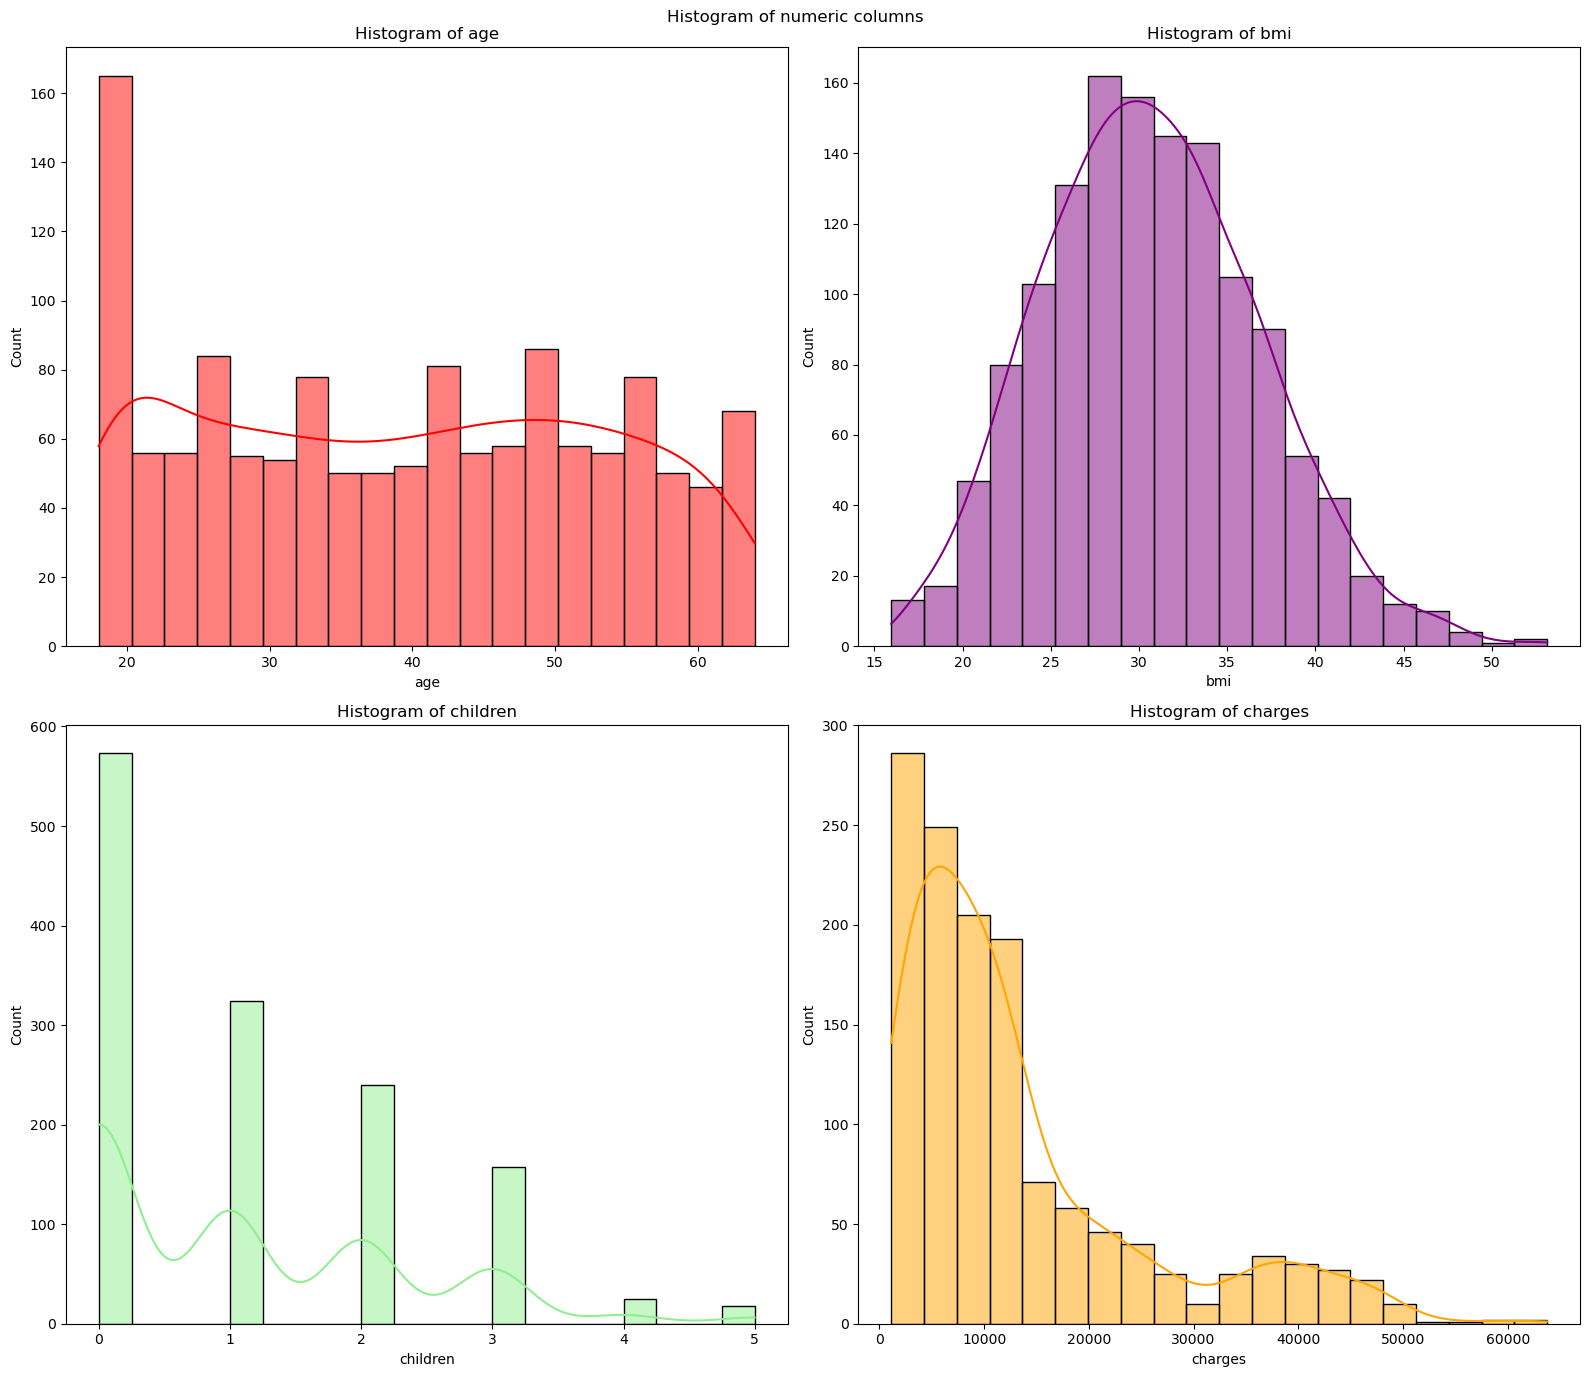

In [10]:
fig, axes = plt.subplots(2,2, figsize=(16,14))
axes = axes.flatten()

numeric_cols = ['age', 'bmi', 'children', 'charges']
colors = ['red', 'purple', 'lightgreen', 'orange']

fig.suptitle("Histogram of numeric columns")

for i,(col,color) in enumerate(zip(numeric_cols, colors)): 
    sns.histplot(df[col],bins=20, kde=True, color=color, ax=axes[i])
    axes[i].set_title(f"Histogram of {col}")

plt.tight_layout()
plt.show()
    

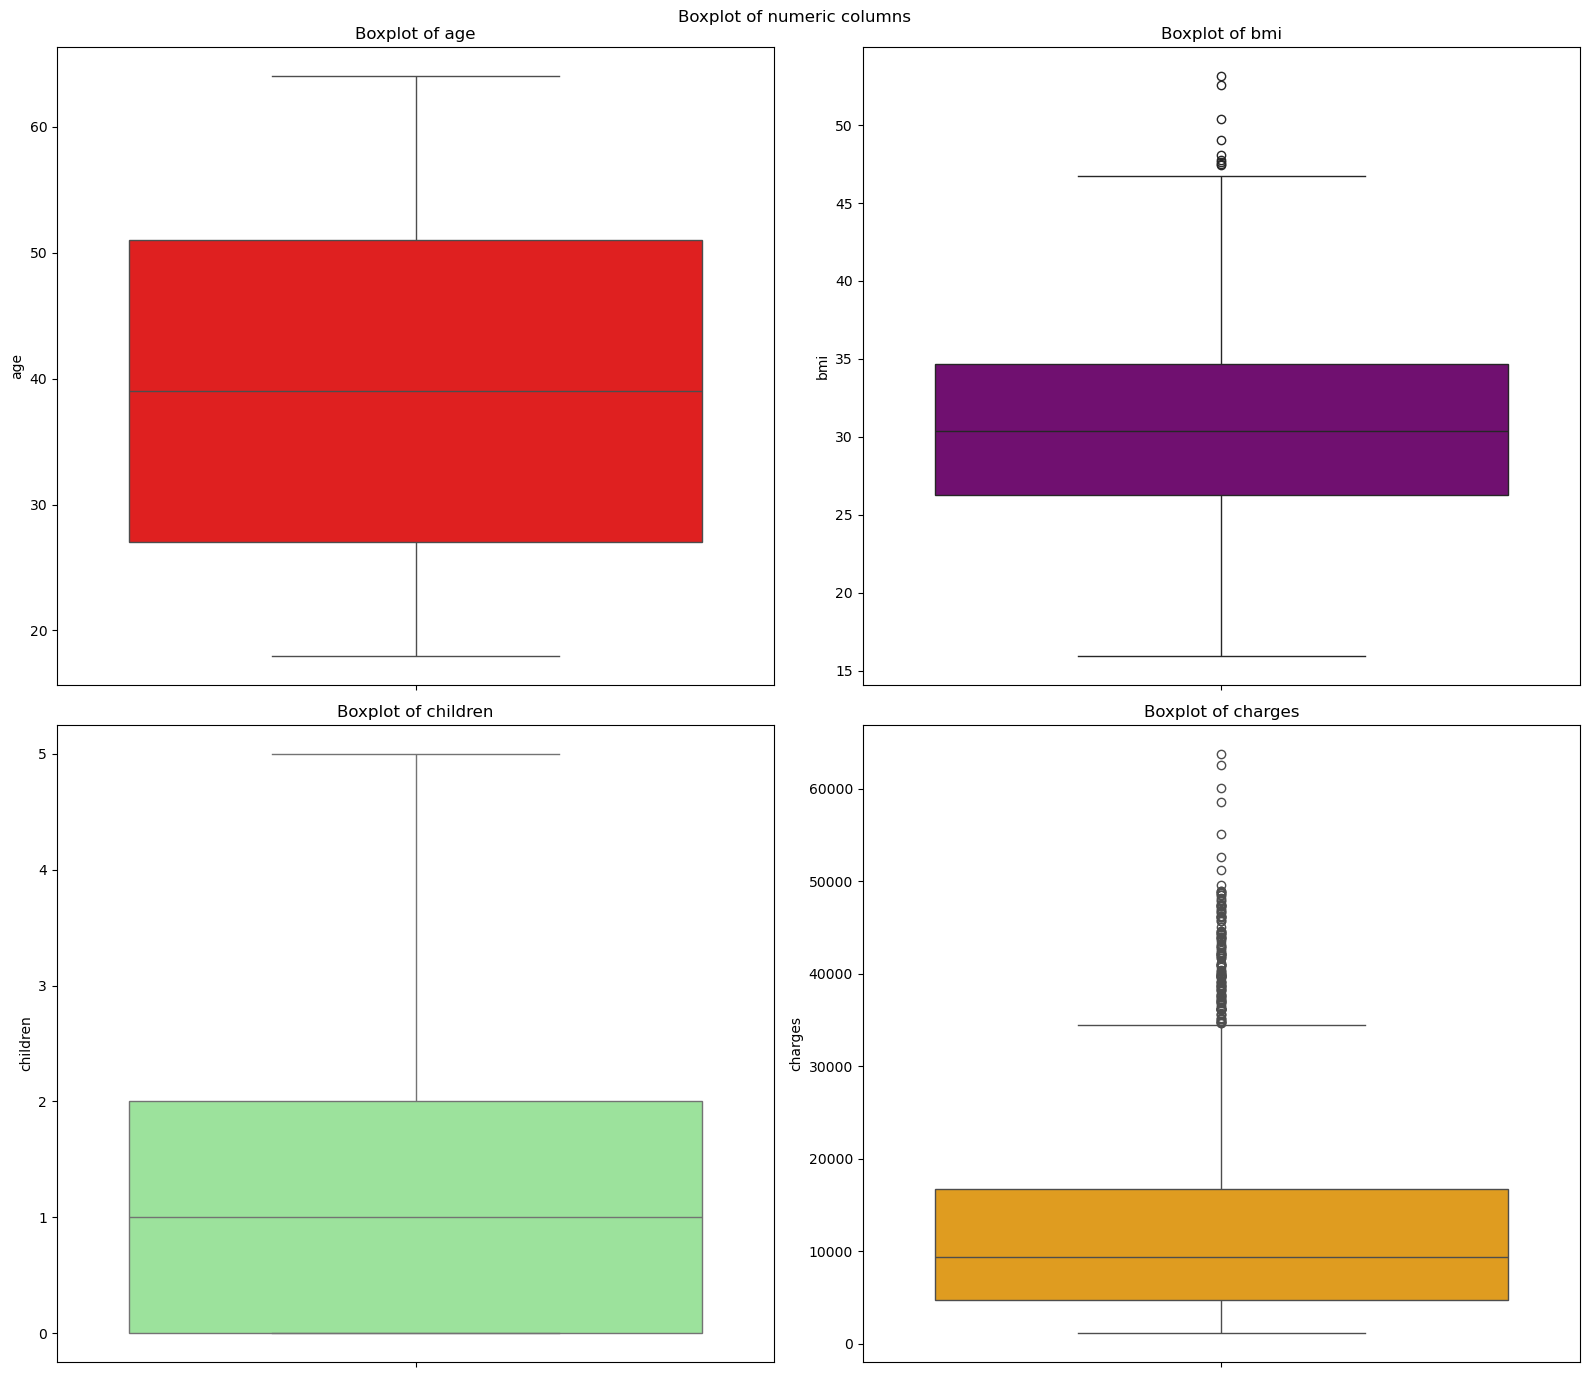

In [11]:
fig, axes = plt.subplots(2,2, figsize=(16,14))
axes = axes.flatten()

fig.suptitle("Boxplot of numeric columns")

for i,(col,color) in enumerate(zip(numeric_cols, colors)): 
    sns.boxplot(df[col], color=color, ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()
    

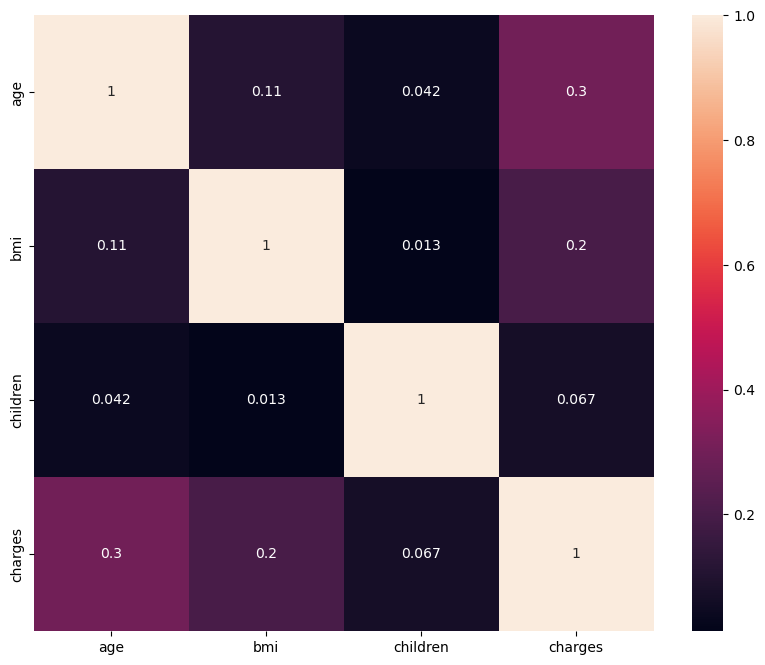

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [13]:
print("\n📌 Categorical Columns:")
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)
print()

for col in cat_cols:
    print(f"  {col}: {df[col].unique()}")


📌 Categorical Columns:
['sex', 'smoker', 'region']

  sex: ['female' 'male']
  smoker: ['yes' 'no']
  region: ['southwest' 'southeast' 'northwest' 'northeast']


In [14]:
# Label encoding 
df['sex'] = df['sex'].map({
    'female' : 1, 
    'male' : 0
})

df['smoker'] = df['smoker'].map({
    'yes' : 1,  
    'no' : 0 
})

print(df.dtypes)

age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region       object
charges     float64
dtype: object


In [15]:
# one hot encoding 
df = pd.get_dummies(df,columns=['region'], drop_first=True)
print(df.dtypes)
print(df.columns.to_list())

age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


In [16]:
bool_col = df.select_dtypes(include='bool').columns
df[bool_col] = df[bool_col].astype(int) 

df.dtypes

age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object

In [17]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0


In [18]:
# Train test split 

X = df.drop(columns=['charges'], axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


In [19]:
X_train.sample(10)

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
1071,63,0,31.445,0,0,0,0,0
1138,33,0,30.250,0,0,0,1,0
1101,53,0,28.600,3,0,0,0,1
957,24,0,26.790,1,0,1,0,0
1051,64,0,26.410,0,0,0,0,0
739,29,0,35.500,2,1,0,0,1
229,47,0,25.460,2,0,0,0,0
1080,18,0,21.780,2,0,0,1,0
540,34,1,38.000,3,0,0,0,1
698,56,0,33.725,0,0,1,0,0


In [20]:
y_test.sample(5)

678    12363.54700
479     1824.28540
296    16297.84600
567     7256.72310
107     3877.30425
Name: charges, dtype: float64

In [21]:
print(f"Train size: {X_train.shape}")
print(f"Test size : {X_test.shape}")

Train size: (1069, 8)
Test size : (268, 8)


In [22]:
model = LinearRegression()

model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_.round(2)
}).sort_values('Coefficient', ascending=False, key=abs)

print("\n📌 Feature Coefficients:")
print(coef_df.to_string(index=False))


📌 Feature Coefficients:
         Feature  Coefficient
          smoker     23077.76
region_southeast      -838.92
region_southwest      -659.14
        children       533.01
region_northwest      -391.76
             bmi       318.70
             age       248.21
             sex       101.54


In [24]:
print(f"Slope: {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")

Slope: 248.21072022470435
Intercept: -11194.194349936231


In [25]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# ── Metrics ────────────────────────────────────
train_r2  = r2_score(y_train, y_pred_train)
test_r2   = r2_score(y_test, y_pred_test)
test_mae  = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"\n{'Metric':<20} {'Train':>10} {'Test':>10}")
print("-" * 42)
print(f"{'R2 Score':<20} {train_r2:>10.4f} {test_r2:>10.4f}")
print(f"{'MAE':<20} {'—':>10} {test_mae:>10.0f}")
print(f"{'RMSE':<20} {'—':>10} {test_rmse:>10.0f}")


Metric                    Train       Test
------------------------------------------
R2 Score                 0.7299     0.8069
MAE                           —       4177
RMSE                          —       5956


In [26]:
n = X.shape[0]  # Number of observations 
p = X.shape[1]  # Number of features/predictors

adjusted_r2 = 1 - ((1 - test_r2) * (n - 1) / (n - p - 1))

print(f"R-squared:          {test_r2:.4f}")
print(f"Adjusted R-squared: {adjusted_r2:.4f}")


R-squared:          0.8069
Adjusted R-squared: 0.8058


In [27]:
gap = train_r2 - test_r2
print(f"\n📌 Train-Test Gap: {gap:.4f}")
if gap > 0.10:
    print("⚠️  Overfitting detected!")
elif test_r2 < 0.5:
    print("⚠️  Underfitting detected!")
else:
    print("✅ Model looks good — no overfitting!")



📌 Train-Test Gap: -0.0770
✅ Model looks good — no overfitting!


In [30]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"\n📌 Cross Validation R2 Scores: {cv_scores.round(3)}")
print(f"📌 Mean CV Score : {cv_scores.mean():.4f}")
print(f"📌 Std Dev       : {cv_scores.std():.4f}")


📌 Cross Validation R2 Scores: [0.761 0.707 0.777 0.733 0.756]
📌 Mean CV Score : 0.7467
📌 Std Dev       : 0.0247


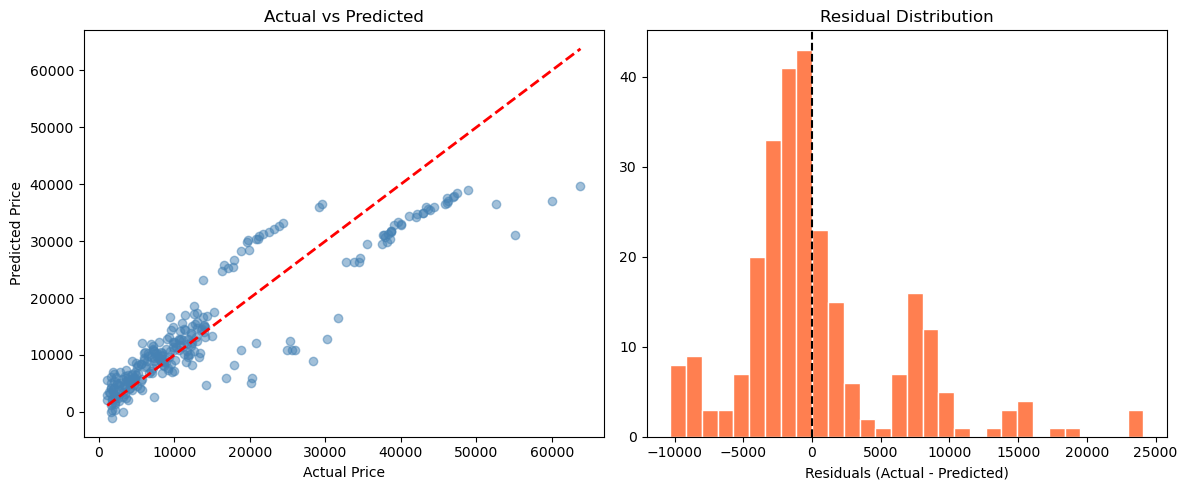

In [38]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_test, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted')

plt.subplot(1, 2, 2)
residuals = y_test - y_pred_test
plt.hist(residuals, bins=30, color='coral', edgecolor='white')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Residuals (Actual - Predicted)')
plt.title('Residual Distribution')

plt.tight_layout()
plt.show()


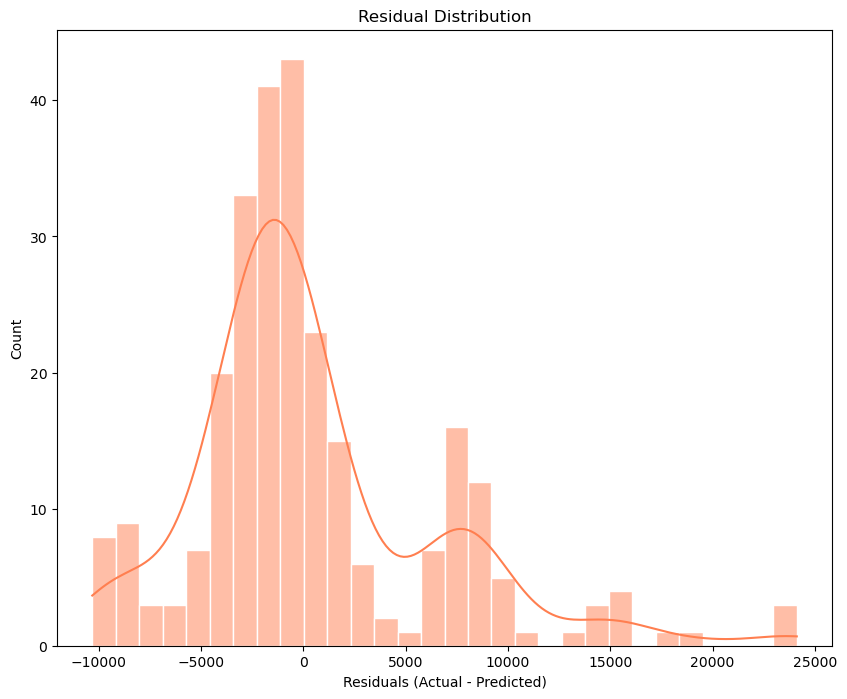

In [40]:
plt.figure(figsize=(10,8))
residuals = y_test - y_pred_test
sns.histplot(residuals, bins=30, color='coral',kde=True, edgecolor='white')
plt.xlabel('Residuals (Actual - Predicted)')
plt.title('Residual Distribution')

plt.show()